In [22]:
#import librires

import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas
!pip install opendatasets
import opendatasets as od
from google.colab import userdata
import os

In [23]:
#load data from kaggle

os.environ['KAGGLE_USERNAME'] ="basemmorad"
os.environ['KAGGLE_KEY'] ="7b2fbf771941745848a7e98bf707751d"

data="https://www.kaggle.com/datasets/aryashah2k/breast-ultrasound-images-dataset/data"
od.download(data)




Skipping, found downloaded files in "./breast-ultrasound-images-dataset" (use force=True to force download)


In [24]:
# Count total files per class

data_path = "/content/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

for folder in os.listdir(data_path):
    files = os.listdir(os.path.join(data_path, folder))
    print(f"{folder}: {len(files)} file")


benign: 891 file
normal: 266 file
malignant: 421 file


In [25]:
# count images and maskes per classes
data_path = "/content/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

for folder in os.listdir(data_path):
    folder_path = os.path.join(data_path, folder)
    all_files  = os.listdir(folder_path)
    images = [f for f in all_files if 'mask' not in f]
    masks  = [f for f in all_files if 'mask' in f]
    print(f"{folder} → images: {len(images)} | masks: {len(masks)}")

benign → images: 437 | masks: 454
normal → images: 133 | masks: 133
malignant → images: 210 | masks: 211


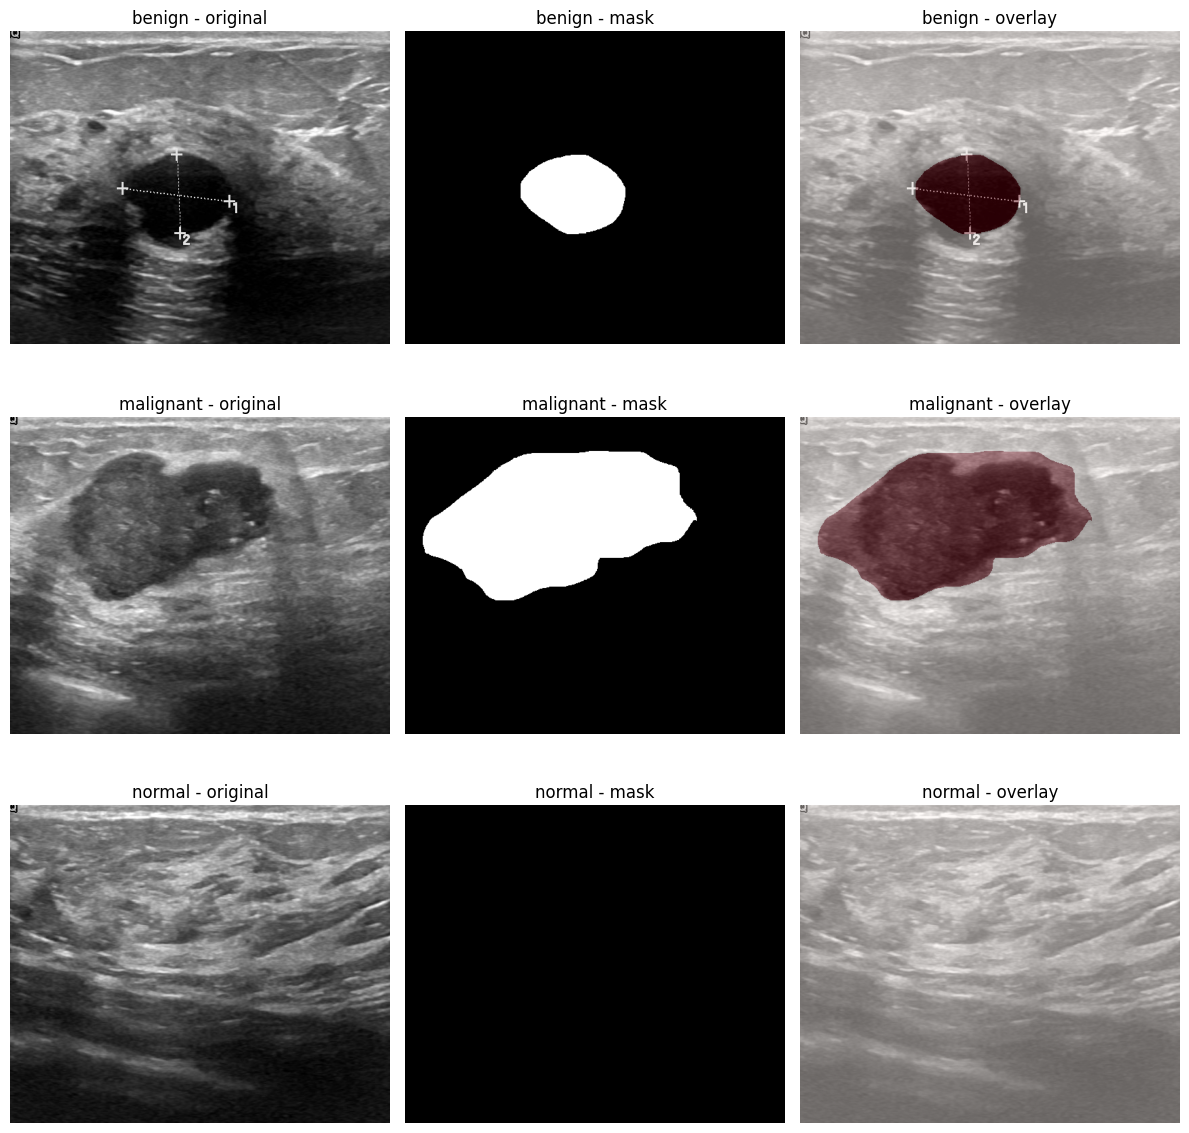

In [18]:
# Display sample images with their masks and overlay for each class
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

classes = ["benign", "malignant", "normal"]

for row, cls in enumerate(classes):
    folder_path = os.path.join(data_path, cls)
    images = [f for f in os.listdir(folder_path) if 'mask' not in f]

    img_name  = images[0]
    mask_name = img_name.replace('.png', '_mask.png')

    img  = cv2.imread(os.path.join(folder_path, img_name))
    img  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(os.path.join(folder_path, mask_name), cv2.IMREAD_GRAYSCALE)

    axes[row][0].imshow(img)
    axes[row][0].set_title(f"{cls} - original")
    axes[row][0].axis('off')

    axes[row][1].imshow(mask, cmap='gray')
    axes[row][1].set_title(f"{cls} - mask")
    axes[row][1].axis('off')

    axes[row][2].imshow(img)
    axes[row][2].imshow(mask, alpha=0.4, cmap='Reds')
    axes[row][2].set_title(f"{cls} - overlay")
    axes[row][2].axis('off')

plt.tight_layout()
plt.show()

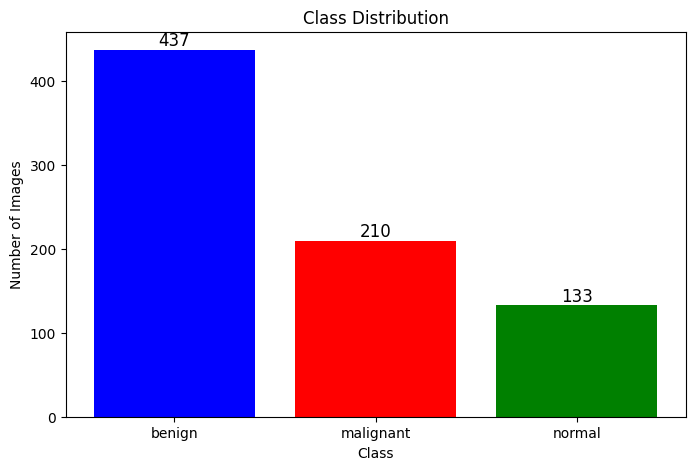

In [21]:
# Count images per class and plot class distribution without masks

class_counts = {}
for cls in classes:
    folder_path = os.path.join(data_path, cls)
    images = [f for f in os.listdir(folder_path) if 'mask' not in f]
    class_counts[cls] = len(images)

plt.figure(figsize=(8, 5))
plt.bar(class_counts.keys(), class_counts.values(), color=['blue', 'red', 'green'])
plt.title('Class Distribution')
plt.xlabel('Class')
plt.ylabel('Number of Images')
for i, (cls, count) in enumerate(class_counts.items()):
    plt.text(i, count + 5, str(count), ha='center', fontsize=12)
plt.show()